In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler

archivo = '/content/drive/MyDrive/2do cuatrimestre/Aprendizaje automatico /set_de_datos/titanic (2).xls'
df = pd.read_excel(archivo)
display(df.head())
print("\nTipo de datos:")
df.info()
print("\nValores faltantes por columna:")
print(df.isnull().sum())

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"



Tipo de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB

Valores faltantes por columna:
pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket         

#Imputación de Valores Faltantes:

In [ ]:
# Copia del DataFrame
df_knn = df.copy()
#Imptacion de age
columnas_age = ['age', 'fare', 'pclass', 'sibsp', 'parch']
imputador_knn = KNNImputer(n_neighbors=5)
df_knn[columnas_age] = imputador_knn.fit_transform(df_knn[columnas_age])

#Imputación de embarked con la moda
moda_embarked = df_knn['embarked'].mode()[0]
df_knn['embarked'].fillna(moda_embarked, inplace=True)

#Extraigo primera letra de cabina
df_knn['cabin_letter'] = df_knn['cabin'].astype(str).str[0]

#Reemplazo 'n' (de 'nan') por np.nan
df_knn['cabin_letter'] = df_knn['cabin_letter'].replace('n', np.nan)

#Relleno los nulos con la categoría 'missing'
df_knn['cabin_letter_filled'] = df_knn['cabin_letter'].fillna('missing')

#Codificar con OrdinalEncoder (ahora incluyendo 'missing')
encoder = OrdinalEncoder()
df_knn['cabin_encoded'] = encoder.fit_transform(df_knn[['cabin_letter_filled']])

#Reemplazo de nuevo 'missing' por np.nan para que KNNImputer lo impute
df_knn['cabin_encoded'] = df_knn['cabin_encoded'].where(df_knn['cabin_letter'].notna(), np.nan)

#Imputación de cabin
columnas_cabin = ['cabin_encoded', 'pclass', 'fare', 'sibsp', 'parch', 'age']
imputador = KNNImputer(n_neighbors=5)
df_knn[columnas_cabin] = imputador.fit_transform(df_knn[columnas_cabin])

#Redondear y convertir a entero
df_knn['cabin_encoded'] = df_knn['cabin_encoded'].round().astype(int)

#Convertir de nuevo a letra usando inverse_transform
df_knn['cabin_letter_imputed'] = encoder.inverse_transform(df_knn[['cabin_encoded']].values.reshape(-1, 1)).flatten()

#Eliminar columnas intermedias
df_knn.drop(columns=['cabin', 'cabin_letter', 'cabin_letter_filled', 'cabin_encoded'], inplace=True)

df_knn.drop(columns=['boat', 'body', 'home.dest'], inplace=True)

print('Valores faltantes luego de la imputacion\n',df_knn.isnull().sum())


/tmp/ipython-input-19-3647044620.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_knn['embarked'].fillna(moda_embarked, inplace=True)


Valores faltantes luego de la imputacion
 pclass                  0
survived                0
name                    0
sex                     0
age                     0
sibsp                   0
parch                   0
ticket                  0
fare                    0
embarked                0
cabin_letter_imputed    0
dtype: int64


# Ingenieria de variables

In [ ]:
df_knn['tamaño_familia'] = df_knn['sibsp'].astype(int) + df_knn['parch'].astype(int) + 1
df_knn['is_alone'] = (df_knn['tamaño_familia'] == 1).astype(int)
df['titulo'] = df['name'].str.split(',').str[1].str.split('.').str[0].str.strip()
df_knn['titulo'] = df['titulo']
le_title = LabelEncoder()
df_knn['titulo'] = le_title.fit_transform(df_knn['titulo'])

#Codificación de Variables Categóricas y Ordinales:

In [ ]:
X = df_knn.drop(columns=['survived', 'name', 'ticket'])
y = df_knn['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)
columnas_numericas = ['age', 'fare', 'pclass', 'sibsp', 'parch']
columnas_nominales = ['sex', 'embarked']
columnas_ordinales = ['cabin_letter_imputed']

t_norm = ("normalizador", MinMaxScaler(), columnas_numericas)
t_nominal = ("onehot", OneHotEncoder(sparse_output=False, handle_unknown='ignore'), columnas_nominales)
orden_cabinas = [['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'T']]
t_ordinal = ("ordinal", OrdinalEncoder(categories=orden_cabinas), columnas_ordinales)

transformador_columnas = ColumnTransformer(transformers=[t_norm, t_nominal, t_ordinal], remainder='passthrough')

transformador_columnas.fit(X_train)
X_train_transformado = transformador_columnas.transform(X_train)
X_test_transformado = transformador_columnas.transform(X_test)

#Análisis Exploratorio de Datos (EDA):

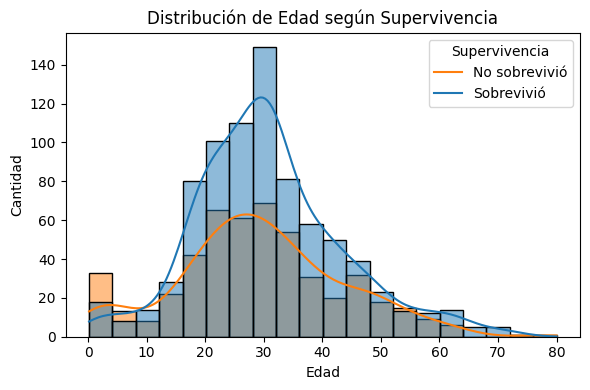

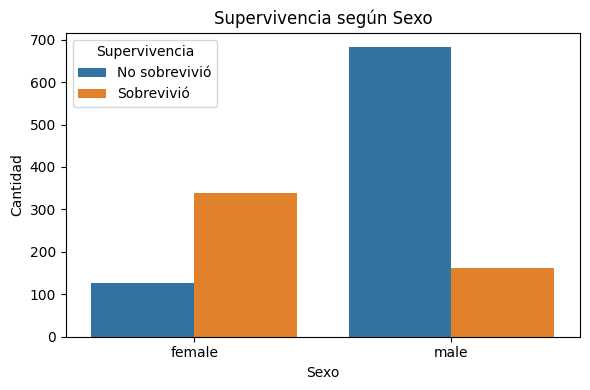

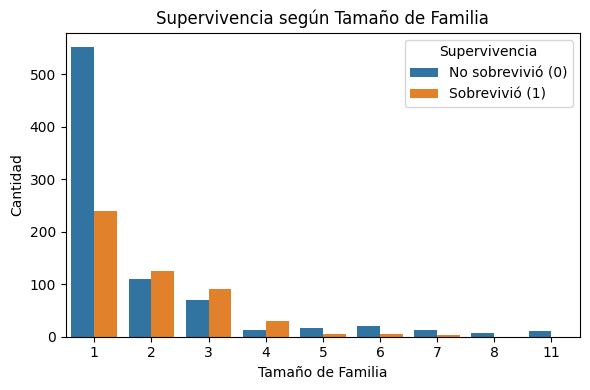

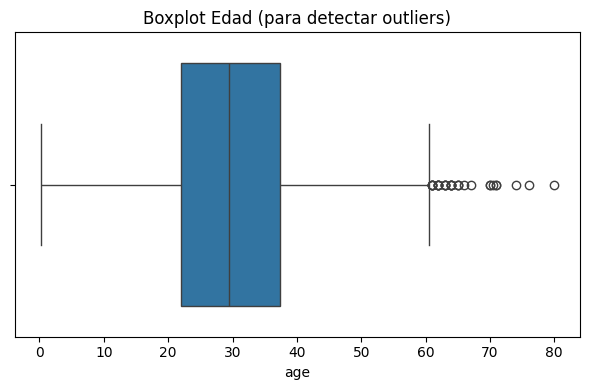

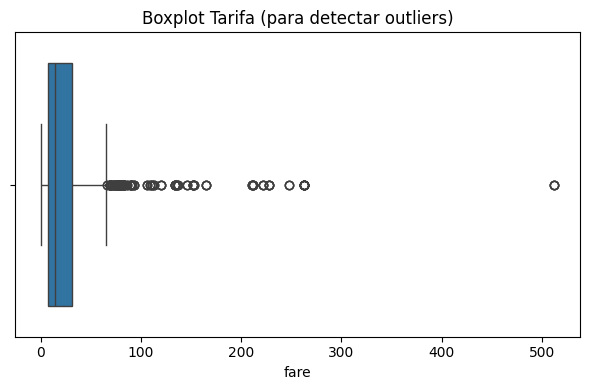

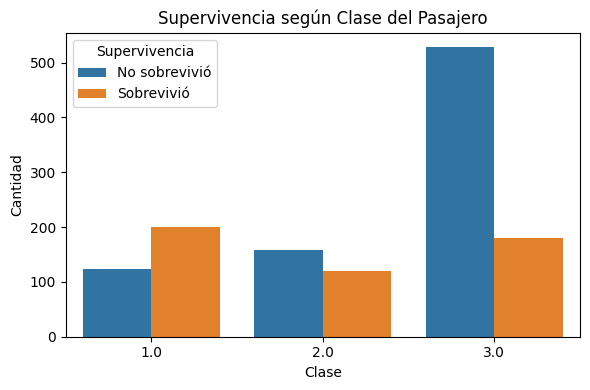

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma de edad según supervivencia
plt.figure(figsize=(6, 4))
sns.histplot(data=df_knn, x='age', hue='survived', bins=20, kde=True)
plt.title('Distribución de Edad según Supervivencia')
plt.xlabel('Edad')
plt.ylabel('Cantidad')
plt.legend(title='Supervivencia', labels=['No sobrevivió', 'Sobrevivió'])
plt.tight_layout()
plt.show()

# Conteo de sexo según supervivencia
plt.figure(figsize=(6, 4))
sns.countplot(data=df_knn, x='sex', hue='survived')
plt.title('Supervivencia según Sexo')
plt.xlabel('Sexo')
plt.ylabel('Cantidad')
plt.legend(title='Supervivencia', labels=['No sobrevivió', 'Sobrevivió'])
plt.tight_layout()
plt.show()

# Supervivencia según tamaño de familia
plt.figure(figsize=(6, 4))
sns.countplot(data=df_knn, x='tamaño_familia', hue='survived')
plt.title('Supervivencia según Tamaño de Familia')
plt.xlabel('Tamaño de Familia')
plt.ylabel('Cantidad')
plt.legend(title='Supervivencia', labels=['No sobrevivió (0)', 'Sobrevivió (1)'])
plt.tight_layout()
plt.show()

# Boxplot de edad
plt.figure(figsize=(6, 4))
sns.boxplot(x='age', data=df_knn)
plt.title('Boxplot Edad (para detectar outliers)')
plt.tight_layout()
plt.show()

# Boxplot de tarifa
plt.figure(figsize=(6, 4))
sns.boxplot(x='fare', data=df_knn)
plt.title('Boxplot Tarifa (para detectar outliers)')
plt.tight_layout()
plt.show()

# Conteo por clase de pasajero
plt.figure(figsize=(6, 4))
sns.countplot(data=df_knn, x='pclass', hue='survived')
plt.title('Supervivencia según Clase del Pasajero')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.legend(title='Supervivencia', labels=['No sobrevivió', 'Sobrevivió'])
plt.tight_layout()
plt.show()

#Modelado de Aprendizaje Automático:

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score


X = df_knn.drop(columns=['survived', 'name', 'ticket'])
X_val_train, X_val_test, y_val_train, y_val_test = train_test_split(
    X_train_transformado, y_train, test_size=0.3, random_state=123)

print(" Regresión Logística")
for c in [0.01, 0.1, 1, 10, 100]:
    modelo = LogisticRegression(C=c, max_iter=1000, random_state=123)
    modelo.fit(X_val_train, y_val_train)
    y_pred = modelo.predict(X_val_test)
    acc = accuracy_score(y_val_test, y_pred)
    f1 = f1_score(y_val_test, y_pred)
    print(f"C={c} → Accuracy: {acc:.3f} | F1: {f1:.3f}")


print("\n Árbol de Decisión")
for d in range(2, 10):
    modelo = DecisionTreeClassifier(max_depth=d, random_state=123)
    modelo.fit(X_val_train, y_val_train)
    y_pred = modelo.predict(X_val_test)
    acc = accuracy_score(y_val_test, y_pred)
    f1 = f1_score(y_val_test, y_pred)
    print(f"Max Depth={d} → Accuracy: {acc:.3f} | F1: {f1:.3f}")


print("\n KNN")
for k in range(2, 10):
    for peso in ['uniform', 'distance']:
        modelo = KNeighborsClassifier(n_neighbors=k, weights=peso)
        modelo.fit(X_val_train, y_val_train)
        y_pred = modelo.predict(X_val_test)
        acc = accuracy_score(y_val_test, y_pred)
        f1 = f1_score(y_val_test, y_pred)
        print(f"k={k}, peso={peso} → Accuracy: {acc:.3f} | F1: {f1:.3f}")

 Regresión Logística
C=0.01 → Accuracy: 0.771 | F1: 0.625
C=0.1 → Accuracy: 0.797 | F1: 0.704
C=1 → Accuracy: 0.800 | F1: 0.710
C=10 → Accuracy: 0.790 | F1: 0.697
C=100 → Accuracy: 0.797 | F1: 0.706

 Árbol de Decisión
Max Depth=2 → Accuracy: 0.797 | F1: 0.722
Max Depth=3 → Accuracy: 0.813 | F1: 0.731
Max Depth=4 → Accuracy: 0.794 | F1: 0.714
Max Depth=5 → Accuracy: 0.790 | F1: 0.649
Max Depth=6 → Accuracy: 0.803 | F1: 0.718
Max Depth=7 → Accuracy: 0.813 | F1: 0.720
Max Depth=8 → Accuracy: 0.810 | F1: 0.714
Max Depth=9 → Accuracy: 0.813 | F1: 0.728

 KNN
k=2, peso=uniform → Accuracy: 0.762 | F1: 0.607
k=2, peso=distance → Accuracy: 0.730 | F1: 0.626
k=3, peso=uniform → Accuracy: 0.790 | F1: 0.703
k=3, peso=distance → Accuracy: 0.778 | F1: 0.688
k=4, peso=uniform → Accuracy: 0.794 | F1: 0.683
k=4, peso=distance → Accuracy: 0.775 | F1: 0.682
k=5, peso=uniform → Accuracy: 0.787 | F1: 0.705
k=5, peso=distance → Accuracy: 0.784 | F1: 0.702
k=6, peso=uniform → Accuracy: 0.790 | F1: 0.683
k=6

#Evalución

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier

modelo_final = DecisionTreeClassifier(max_depth=3, random_state=123)
modelo_final.fit(X_train_transformado, y_train)

y_pred_test = modelo_final.predict(X_test_transformado)

print("\n Evaluación Final del Mejor Modelo en Test:")
print(classification_report(y_test, y_pred_test))
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_test))



 Evaluación Final del Mejor Modelo en Test:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       154
           1       0.82      0.72      0.77       108

    accuracy                           0.82       262
   macro avg       0.82      0.81      0.81       262
weighted avg       0.82      0.82      0.82       262


Matriz de Confusión:
[[137  17]
 [ 30  78]]
